# DeepCSAT – Ecommerce Customer Satisfaction Score Prediction

## 01. Imports

### ➤ *Import Libraries*

In [ ]:
# Install required libraries (uncomment if needed)
# %pip install pandas numpy scikit-learn joblib python-docx --quiet

import os
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, accuracy_score, f1_score
import joblib

print("✅ Imports OK")

✅ Imports OK


## 02. Uploading Files

### ➤ *Mount Google Drive*

In [ ]:
from google.colab import drive
drive.mount('/content/drive')
PROJECT_DIR = '/content/drive/MyDrive/Colab Notebooks/Ecommerce Customer Satisfaction Score Prediction/'
print("✅ Project dir:", PROJECT_DIR)

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
✅ Project dir: /content/drive/MyDrive/Colab Notebooks/Ecommerce Customer Satisfaction Score Prediction/


### ➤ *Create a project folder in Drive*

In [ ]:
import os
project_folder = '/content/drive/MyDrive/Ecommerce Customer Satisfaction Score Prediction'
os.makedirs(project_folder, exist_ok=True)
print("✅ Project folder ready at:", project_folder)

✅ Project folder ready at: /content/drive/MyDrive/Ecommerce Customer Satisfaction Score Prediction


### ➤ *File(s) check*

In [ ]:
import os

# Path to your project folder in Google Drive
project_folder = '/content/drive/MyDrive/Ecommerce Customer Satisfaction Score Prediction'

# List files
files = os.listdir(project_folder)
print("Files in project folder:")
for f in files:
    print(f)

Files in project folder:
Sample_ML_Submission_Template-2.ipynb
eCommerce_Customer_support_data.csv


## 03. Loading Dataset

In [ ]:
import os

def check_directory(path):
    """
    Print contents of a directory with status markers.
    📁 = folder
    ✅ = file
    """
    if not os.path.exists(path):
        print(f"❌ Path does not exist: {path}")
        return

    print(f"\nContents of: {path}\n" + "-"*50)

    items = os.listdir(path)
    if not items:
        print("⚠️ Directory is empty.")
        return

    for item in sorted(items):
        item_path = os.path.join(path, item)
        if os.path.isdir(item_path):
            print(f"📁 {item}/")
        else:
            print(f"✅ {item}")
    print("-"*50)

# Example: check your project folder in Drive
check_directory('/content/drive/MyDrive/Ecommerce Customer Satisfaction Score Prediction')


Contents of: /content/drive/MyDrive/Ecommerce Customer Satisfaction Score Prediction
--------------------------------------------------
✅ Sample_ML_Submission_Template-2.ipynb
✅ eCommerce_Customer_support_data.csv
--------------------------------------------------


### ➤ *Auto detect .csv File*

In [ ]:
# B1: auto_detect_csv helper (small)
def auto_detect_csv(folder=None):
    if folder is None:
        folder = project_folder  # expects project_folder set earlier
    files = [f for f in os.listdir(folder) if f.lower().endswith('.csv')]
    if not files:
        raise FileNotFoundError(f"No CSV files found in {folder}")
    # choose the first CSV (change logic if you want different)
    return os.path.join(folder, files[0])

In [ ]:
# C1: safe_read_csv helper (small)
def safe_read_csv(path, nrows=None, dtype=None):
    try:
        df = pd.read_csv(path, nrows=nrows, dtype=dtype)
    except Exception as e:
        # fallback: try with low_memory False to avoid dtype issues
        df = pd.read_csv(path, nrows=nrows, dtype=dtype, low_memory=False)
    return df

## 04. Data Assessment

### ➤ *Dataset Rows & Columns Count*

In [ ]:
# Load the dataset
csv_path = auto_detect_csv()
df = safe_read_csv(csv_path)

print("✅ Dataset loaded successfully.")

# Shape of dataset
print("ROWS:", df.shape[0], "COLUMNS:", df.shape[1])

✅ Dataset loaded successfully.
ROWS: 85907 COLUMNS: 20


### ➤ *Dataset Type*

In [ ]:
### Dataset Type
print(df.dtypes)

Unique id                   object
channel_name                object
category                    object
Sub-category                object
Customer Remarks            object
Order_id                    object
order_date_time             object
Issue_reported at           object
issue_responded             object
Survey_response_Date        object
Customer_City               object
Product_category            object
Item_price                 float64
connected_handling_time    float64
Agent_name                  object
Supervisor                  object
Manager                     object
Tenure Bucket               object
Agent Shift                 object
CSAT Score                   int64
dtype: object


### ➤ *Dataset First few Rows*

In [ ]:
 ### Preview first rows
 display(df.head())

,Unique id,channel_name,category,Sub-category,Customer Remarks,Order_id,order_date_time,Issue_reported at,issue_responded,Survey_response_Date,Customer_City,Product_category,Item_price,connected_handling_time,Agent_name,Supervisor,Manager,Tenure Bucket,Agent Shift,CSAT Score
0,7e9ae164-6a8b-4521-a2d4-58f7c9fff13f,Outcall,Product Queries,Life Insurance,NaN,c27c9bb4-fa36-4140-9f1f-21009254ffdb,NaN,01/08/2023 11:13,01/08/2023 11:47,01-Aug-23,NaN,NaN,NaN,NaN,Richard Buchanan,Mason Gupta,Jennifer Nguyen,On Job Training,Morning,5
1,b07ec1b0-f376-43b6-86df-ec03da3b2e16,Outcall,Product Queries,Product Specific Information,NaN,d406b0c7-ce17-4654-b9de-f08d421254bd,NaN,01/08/2023 12:52,01/08/2023 12:54,01-Aug-23,NaN,NaN,NaN,NaN,Vicki Collins,Dylan Kim,Michael Lee,>90,Morning,5
2,200814dd-27c7-4149-ba2b-bd3af3092880,Inbound,Order Related,Installation/demo,NaN,c273368d-b961-44cb-beaf-62d6fd6c00d5,NaN,01/08/2023 20:16,01/08/2023 20:38,01-Aug-23,NaN,NaN,NaN,NaN,Duane Norman,Jackson Park,William Kim,On Job Training,Evening,5
3,eb0d3e53-c1ca-42d3-8486-e42c8d622135,Inbound,Returns,Reverse Pickup Enquiry,NaN,5aed0059-55a4-4ec6-bb54-97942092020a,NaN,01/08/2023 20:56,01/08/2023 21:16,01-Aug-23,NaN,NaN,NaN,NaN,Patrick Flores,Olivia Wang,John Smith,>90,Evening,5
4,ba903143-1e54-406c-b969-46c52f92e5df,Inbound,Cancellation,Not Needed,NaN,e8bed5a9-6933-4aff-9dc6-ccefd7dcde59,NaN,01/08/2023 10:30,01/08/2023 10:32,01-Aug-23,NaN,NaN,NaN,NaN,Christopher Sanchez,Austin Johnson,Michael Lee,0-30,Morning,5


### ➤ *Dataset Last few Rows*

In [ ]:
 ### Preview last rows
 display(df.tail())

,Unique id,channel_name,category,Sub-category,Customer Remarks,Order_id,order_date_time,Issue_reported at,issue_responded,Survey_response_Date,Customer_City,Product_category,Item_price,connected_handling_time,Agent_name,Supervisor,Manager,Tenure Bucket,Agent Shift,CSAT Score
85902,505ea5e7-c475-4fac-ac36-1d19a4cb610f,Inbound,Refund Related,Refund Enquiry,NaN,1b5a2b9c-a95f-405f-a42e-5b1b693f3dc9,NaN,30/08/2023 23:20,31/08/2023 07:22,31-Aug-23,NaN,NaN,NaN,NaN,Brandon Leon,Ethan Tan,William Kim,On Job Training,Morning,4
85903,44b38d3f-1523-4182-aba2-72917586647c,Inbound,Order Related,Seller Cancelled Order,Supported team customer executive good,d0e8a817-96d5-4ace-bb82-adec50398e22,NaN,31/08/2023 08:15,31/08/2023 08:17,31-Aug-23,NaN,NaN,NaN,NaN,Linda Foster,Noah Patel,Emily Chen,>90,Morning,5
85904,723bce2c-496c-4aa8-a64b-ca17004528f0,Inbound,Order Related,Order status enquiry,need to improve with proper details.,bdefe788-ccec-4eda-8ca4-51045e68db8a,NaN,31/08/2023 18:57,31/08/2023 19:02,31-Aug-23,NaN,NaN,NaN,NaN,Kimberly Martinez,Aiden Patel,Olivia Tan,On Job Training,Evening,5
85905,707528ee-6873-4192-bfa9-a491f1c08ab5,Inbound,Feedback,UnProfessional Behaviour,NaN,a031ec28-0c5e-450e-95b2-592342c40bc4,NaN,31/08/2023 19:59,31/08/2023 20:00,31-Aug-23,NaN,NaN,NaN,NaN,Daniel Martin,Olivia Suzuki,Olivia Tan,>90,Morning,4
85906,07c7a878-0d5a-42e0-97ef-de59abec0238,Inbound,Returns,Reverse Pickup Enquiry,NaN,3230db30-f8da-4c44-8636-ec76d1d3d4f3,NaN,31/08/2023 23:36,31/08/2023 23:37,31-Aug-23,NaN,NaN,NaN,NaN,Elizabeth Guerra,Nathan Patel,Jennifer Nguyen,On Job Training,Evening,5


### ➤ *Basic Statistics*

In [ ]:
### Statistical summary
display(df.describe().T)

,count,mean,std,min,25%,50%,75%,max
Item_price,17206.0,5660.774846,12825.728411,0.0,392.0,979.0,2699.75,164999.0
connected_handling_time,242.0,462.400826,246.295037,0.0,293.0,427.0,592.25,1986.0
CSAT Score,85907.0,4.242157,1.378903,1.0,4.0,5.0,5.00,5.0


### ➤ *Dataset Info*

In [ ]:
### Dataset info
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 85907 entries, 0 to 85906
Data columns (total 20 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   Unique id                85907 non-null  object 
 1   channel_name             85907 non-null  object 
 2   category                 85907 non-null  object 
 3   Sub-category             85907 non-null  object 
 4   Customer Remarks         28742 non-null  object 
 5   Order_id                 67675 non-null  object 
 6   order_date_time          17214 non-null  object 
 7   Issue_reported at        85907 non-null  object 
 8   issue_responded          85907 non-null  object 
 9   Survey_response_Date     85907 non-null  object 
 10  Customer_City            17079 non-null  object 
 11  Product_category         17196 non-null  object 
 12  Item_price               17206 non-null  float64
 13  connected_handling_time  242 non-null    float64
 14  Agent_name            

### ➤ *Unique Values*

In [ ]:
### Unique values per column
for col in df.columns:
    print(col, ":", df[col].nunique())

Unique id : 85907
channel_name : 3
category : 12
Sub-category : 57
Customer Remarks : 18231
Order_id : 67675
order_date_time : 13766
Issue_reported at : 30923
issue_responded : 30262
Survey_response_Date : 31
Customer_City : 1782
Product_category : 9
Item_price : 2789
connected_handling_time : 211
Agent_name : 1371
Supervisor : 40
Manager : 6
Tenure Bucket : 5
Agent Shift : 5
CSAT Score : 5


### ➤ *Missing Values*

In [ ]:
missing_before = df.isnull().sum()
missing_before = missing_before[missing_before>0]
print("Missing values before handling:")
print(missing_before)

Missing values before handling:
Customer Remarks           57165
Order_id                   18232
order_date_time            68693
Customer_City              68828
Product_category           68711
Item_price                 68701
connected_handling_time    85665
dtype: int64


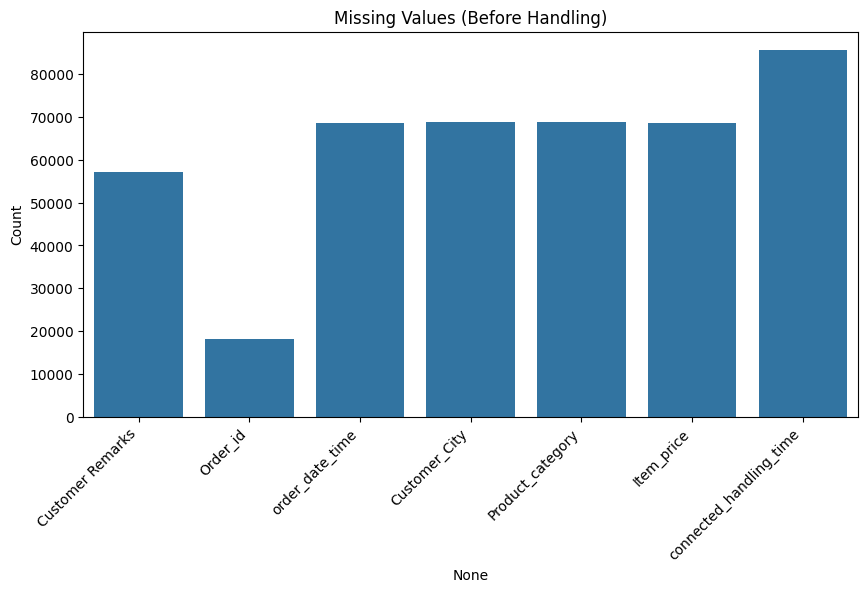

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt

if not missing_before.empty:
    plt.figure(figsize=(10,5))
    sns.barplot(x=missing_before.index, y=missing_before.values)
    plt.xticks(rotation=45, ha='right')
    plt.title("Missing Values (Before Handling)")
    plt.ylabel("Count")
    plt.show()
else:
    print("✅ No missing values before handling.")

### ➤ *Duplicate Values*

In [ ]:
# Count duplicate rows before handling
dup_count_before = df.duplicated().sum()
print(f"Duplicate rows before handling: {dup_count_before}")

if dup_count_before > 0:
    print("⚠️ Dataset has duplicate rows.")
else:
    print("✅ No duplicate rows before handling.")

Duplicate rows before handling: 0
✅ No duplicate rows before handling.


## 05. Data Cleaning

### ➤ *Missing values handling*

In [ ]:
import numpy as np

# Separate columns by type
num_cols = df.select_dtypes(include=[np.number]).columns.tolist()
cat_cols = df.select_dtypes(include=['object','category']).columns.tolist()
datetime_cols = df.select_dtypes(include=['datetime']).columns.tolist()

# Remove datetime cols from imputation
for c in datetime_cols:
    if c in num_cols: num_cols.remove(c)
    if c in cat_cols: cat_cols.remove(c)

# Numeric: median
for c in num_cols:
    if df[c].isnull().sum() > 0:
        df[c].fillna(df[c].median(), inplace=True)

# Categorical: Unknown
for c in cat_cols:
    if df[c].isnull().sum() > 0:
        df[c].fillna("Unknown", inplace=True)

print("✅ Missing value imputation done.")

/tmp/ipython-input-2695405752.py:16: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df[c].fillna(df[c].median(), inplace=True)
/tmp/ipython-input-2695405752.py:21: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 

✅ Missing value imputation done.


### ➤ *Missing values after handling*

In [ ]:
missing_counts_after = df.isnull().sum()
missing_counts_after = missing_counts_after[missing_counts_after > 0]

if missing_counts_after.empty:
    print("✅ No missing values remain after handling.")
else:
    print("Columns still with missing values:")
    print(missing_counts_after)

    # Visual chart
    plt.figure(figsize=(10,5))
    sns.barplot(x=missing_counts_after.index, y=missing_counts_after.values)
    plt.xticks(rotation=45, ha='right')
    plt.title("Missing Values Per Column (After Handling)")
    plt.ylabel("Count of Missing Values")
    plt.show()

✅ No missing values remain after handling.


In [ ]:
if not missing_counts_after.empty:
    plt.figure(figsize=(10,5))
    sns.barplot(x=missing_counts_after.index, y=missing_counts_after.values)
    plt.xticks(rotation=45, ha='right')
    plt.title("Missing Values (After Handling)")
    plt.ylabel("Count")
    plt.show()
else:
    print("✅ No missing values remain.")

✅ No missing values remain.


### *➤ Duplicate values handling*

In [ ]:
if dup_count_before > 0:
    df = df.drop_duplicates()
    print(f"✅ Removed {dup_count_before} duplicate rows.")
    print(f"New dataset shape: {df.shape}")
else:
    print("No duplicates removed because none were found.")

No duplicates removed because none were found.


### ➤ *Duplicate values after handling*

In [ ]:
dup_count_after = df.duplicated().sum()
print(f"Duplicate rows after handling: {dup_count_after}")

if dup_count_after == 0:
    print("✅ Dataset is now free of duplicate rows.")
else:
    print(f"⚠️ Still {dup_count_after} duplicate rows remain.")

Duplicate rows after handling: 0
✅ Dataset is now free of duplicate rows.


### ➤ *Standardize column names (lowercase + underscores) and inspect important names*

In [ ]:
# Make column names consistent
df.columns = df.columns.str.strip().str.lower().str.replace(" ", "_")

print("✅ Standardized column names:")
print(df.columns.tolist())

✅ Standardized column names:
['unique_id', 'channel_name', 'category', 'sub-category', 'customer_remarks', 'order_id', 'order_date_time', 'issue_reported_at', 'issue_responded', 'survey_response_date', 'customer_city', 'product_category', 'item_price', 'connected_handling_time', 'agent_name', 'supervisor', 'manager', 'tenure_bucket', 'agent_shift', 'csat_score']


### ➤ *Parse Dates + Compute Response Time*

In [ ]:
from dateutil import parser

df_clean = df.copy()
df_clean.columns = [c.strip().replace(" ", "_").replace("-", "_").lower() for c in df_clean.columns]

for col in ["issue_reported_at", "issue_responded", "order_date_time", "survey_response_date"]:
    if col in df_clean.columns:
        df_clean[col] = pd.to_datetime(df_clean[col], errors="coerce")

if "issue_reported_at" in df_clean.columns and "issue_responded" in df_clean.columns:
    df_clean["response_time_minutes"] = (
        df_clean["issue_responded"] - df_clean["issue_reported_at"]
    ).dt.total_seconds() / 60
else:
    df_clean["response_time_minutes"] = np.nan

df_clean[["issue_reported_at", "issue_responded", "response_time_minutes"]].head()

/tmp/ipython-input-1362870651.py:8: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  df_clean[col] = pd.to_datetime(df_clean[col], errors="coerce")
/tmp/ipython-input-1362870651.py:8: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  df_clean[col] = pd.to_datetime(df_clean[col], errors="coerce")


,issue_reported_at,issue_responded,response_time_minutes
0,2023-01-08 11:13:00,2023-01-08 11:47:00,34.0
1,2023-01-08 12:52:00,2023-01-08 12:54:00,2.0
2,2023-01-08 20:16:00,2023-01-08 20:38:00,22.0
3,2023-01-08 20:56:00,2023-01-08 21:16:00,20.0
4,2023-01-08 10:30:00,2023-01-08 10:32:00,2.0


### ➤ *Final Cleaning Summary*

In [ ]:
# Summary after missing & duplicate handling
summary = pd.DataFrame({
    "column": df.columns,
    "dtype": df.dtypes.values,
    "missing_values": df.isnull().sum().values
})

print("Final dataset cleaning summary:")
print(summary)

print(f"\nFinal dataset shape: {df.shape}")

Final dataset cleaning summary:
                     column    dtype  missing_values
0                 unique_id   object               0
1              channel_name   object               0
2                  category   object               0
3              sub-category   object               0
4          customer_remarks   object               0
5                  order_id   object               0
6           order_date_time   object               0
7         issue_reported_at   object               0
8           issue_responded   object               0
9      survey_response_date   object               0
10            customer_city   object               0
11         product_category   object               0
12               item_price  float64               0
13  connected_handling_time  float64               0
14               agent_name   object               0
15               supervisor   object               0
16                  manager   object               0
17            

## 06. Feature engineering

In [ ]:
if "issue_reported_at" in df_clean.columns:
    df_clean["reported_hour"] = df_clean["issue_reported_at"].dt.hour
    df_clean["reported_dayofweek"] = df_clean["issue_reported_at"].dt.day_name()

# ensure text column
if "customer_remarks" not in df_clean.columns:
    for c in df.columns:
        if c.lower().strip() == "customer remarks":
            df_clean["customer_remarks"] = df[c].fillna("").astype(str)
if "customer_remarks" not in df_clean.columns:
    df_clean["customer_remarks"] = ""

df_clean[["customer_remarks", "response_time_minutes", "reported_hour"]].head()

,customer_remarks,response_time_minutes,reported_hour
0,Unknown,34.0,11.0
1,Unknown,2.0,12.0
2,Unknown,22.0,20.0
3,Unknown,20.0,20.0
4,Unknown,2.0,10.0


## 07. Machine Learning (Data Modeling & Deployment)

### ➤ *Feature & Target Preparation*

In [ ]:
if "csat_score" in df_clean.columns:
    target = "csat_score"
else:
    candidates = [c for c in df_clean.columns if "csat" in c]
    target = candidates[0] if candidates else None
assert target is not None, "❌ Target column not found"

df_model = df_clean.dropna(subset=[target]).copy()

feature_cols = [
    "channel_name","category","sub-category","product_category","item_price",
    "connected_handling_time","response_time_minutes","reported_hour",
    "reported_dayofweek","agent_name","customer_remarks"
]
feature_cols = [c for c in feature_cols if c in df_model.columns]

print("✅ Target:", target)
print("✅ Features:", feature_cols)
print("Rows for modeling:", df_model.shape)

✅ Target: csat_score
✅ Features: ['channel_name', 'category', 'product_category', 'item_price', 'connected_handling_time', 'response_time_minutes', 'reported_hour', 'reported_dayofweek', 'agent_name', 'customer_remarks']
Rows for modeling: (85907, 23)


### ➤ *Train / Test Split*

In [ ]:
X = df_model[feature_cols]
y = df_model[target].astype(int)

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, stratify=y, random_state=42
)
print("Train shape:", X_train.shape, " Test shape:", X_test.shape)

Train shape: (68725, 10)  Test shape: (17182, 10)


### ➤ *Preprocessing Pipelines*

In [ ]:
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.feature_extraction.text import TfidfVectorizer

# define feature groups
num_features = [c for c in ["item_price","connected_handling_time","response_time_minutes"] if c in X_train.columns]
cat_features = [c for c in ["channel_name","category","sub-category","product_category","agent_name","reported_dayofweek"] if c in X_train.columns]
text_feature = "customer_remarks" if "customer_remarks" in X_train.columns else None

# transformers
numeric_transformer = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler())
])

cat_transformer = Pipeline([
    ("imputer", SimpleImputer(strategy="constant", fill_value="missing")),
    ("onehot", OneHotEncoder(handle_unknown="ignore", sparse_output=False))
])

text_transformer = Pipeline([
    ("tfidf", TfidfVectorizer(max_features=5000, ngram_range=(1,2), stop_words="english"))
])

# column transformer
transformers = []
if num_features:
    transformers.append(("num", numeric_transformer, num_features))
if cat_features:
    transformers.append(("cat", cat_transformer, cat_features))
if text_feature:
    transformers.append(("txt", text_transformer, text_feature))

preprocessor = ColumnTransformer(transformers=transformers, remainder="drop", sparse_threshold=0)
preprocessor

ColumnTransformer(sparse_threshold=0,
                  transformers=[('num',
                                 Pipeline(steps=[('imputer',
                                                  SimpleImputer(strategy='median')),
                                                 ('scaler', StandardScaler())]),
                                 ['item_price', 'connected_handling_time',
                                  'response_time_minutes']),
                                ('cat',
                                 Pipeline(steps=[('imputer',
                                                  SimpleImputer(fill_value='missing',
                                                                strategy='constant')),
                                                 ('onehot',
                                                  OneHotEncoder(handle_unknown='ignore',
                                                                sparse_output=False))]),
                                 ['channel_name', 'category',
                                  'product_category', 'agent_name',
                                  'reported_dayofweek']),
                                ('txt',
                                 Pipeline(steps=[('tfidf',
                                                  TfidfVectorizer(max_features=5000,
                                                                  ngram_range=(1,
                                                                               2),
                                                                  stop_words='english'))]),
                                 'customer_remarks')])

### ➤ *Train Logistic Regression Model*

In [ ]:
from sklearn.linear_model import LogisticRegression
from sklearn.pipeline import Pipeline
from sklearn.feature_extraction.text import TfidfVectorizer

# reduce TF-IDF dimensionality and simplify solver
preprocessor.transformers = [
    (name, trans, cols) for (name, trans, cols) in preprocessor.transformers
    if name != "txt"
]

# lighter TF-IDF (≤1000 features)
text_transformer = Pipeline([
    ("tfidf", TfidfVectorizer(max_features=1000, stop_words="english"))
])
preprocessor.transformers.append(("txt", text_transformer, "customer_remarks"))

# smaller Logistic Regression (limited iterations, L2 regularization)
log_reg_clf = Pipeline([
    ("preprocessor", preprocessor),
    ("clf", LogisticRegression(
        max_iter=300,        # fewer iterations
        solver="lbfgs",      # more memory-efficient solver
        n_jobs=-1            # parallelize
    ))
])

print("⏳ Training Logistic Regression (compact mode)...")
log_reg_clf.fit(X_train.sample(frac=0.5, random_state=42),
                y_train.sample(frac=0.5, random_state=42))
print("✅ Logistic Regression Model Trained Successfully (memory-optimized)")

⏳ Training Logistic Regression (compact mode)...
✅ Logistic Regression Model Trained Successfully (memory-optimized)


### ➤ *Evaluate Logistic Regression Model*

In [ ]:
from sklearn.metrics import accuracy_score, f1_score, classification_report

# predictions
y_pred_lr = log_reg_clf.predict(X_test)

# metrics
lr_acc = accuracy_score(y_test, y_pred_lr)
lr_f1 = f1_score(y_test, y_pred_lr, average="macro")

print("📊 Logistic Regression Performance")
print("Accuracy:", round(lr_acc, 4))
print("F1 Macro:", round(lr_f1, 4))
print("\nClassification Report:\n", classification_report(y_test, y_pred_lr))

📊 Logistic Regression Performance
Accuracy: 0.7175
F1 Macro: 0.2489

Classification Report:
               precision    recall  f1-score   support

           1       0.62      0.30      0.41      2246
           2       0.00      0.00      0.00       256
           3       0.00      0.00      0.00       512
           4       0.12      0.00      0.01      2244
           5       0.73      0.98      0.83     11924

    accuracy                           0.72     17182
   macro avg       0.29      0.26      0.25     17182
weighted avg       0.60      0.72      0.63     17182



/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


### ➤ *Train Random Forest Model*

In [ ]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.pipeline import Pipeline

# light, memory-safe Random Forest pipeline
rf_clf = Pipeline([
    ("preprocessor", preprocessor),
    ("clf", RandomForestClassifier(
        n_estimators=50,        # fewer trees
        max_depth=15,           # limit tree depth
        min_samples_split=10,   # reduce branching
        min_samples_leaf=5,     # avoid tiny leaves
        random_state=42,
        n_jobs=-1               # parallel threads
    ))
])

print("⏳ Training Random Forest (compact mode)...")

# train on a 50% sample for stability
rf_clf.fit(X_train.sample(frac=0.5, random_state=42),
           y_train.sample(frac=0.5, random_state=42))

print("✅ Random Forest Model Trained Successfully (memory-optimized)")

⏳ Training Random Forest (compact mode)...
✅ Random Forest Model Trained Successfully (memory-optimized)


In [ ]:
# RELOAD BASE DATASET (Drive path version)
# Placement: same cell as before; only path changed

import pandas as pd

print("Reloading eCommerce dataset from Google Drive...")

DATA_PATH = "/content/drive/MyDrive/Ecommerce Customer Satisfaction Score Prediction/eCommerce_Customer_support_data.csv"
df = pd.read_csv(DATA_PATH, low_memory=False)
df.columns = [c.strip().lower().replace(" ", "_").replace("-", "_") for c in df.columns]

if "csat_score" not in df.columns:
    raise KeyError("Column 'csat_score' not found in dataset. Verify CSV structure.")

df_model = df.copy()
df_model = df_model[~df_model["csat_score"].isnull()].reset_index(drop=True)

print("✅ Dataset loaded successfully from Google Drive.")
print("Shape:", df_model.shape)
print("Columns:", list(df_model.columns)[:10], "...")

Reloading eCommerce dataset from Google Drive...
✅ Dataset loaded successfully from Google Drive.
Shape: (85907, 20)
Columns: ['unique_id', 'channel_name', 'category', 'sub_category', 'customer_remarks', 'order_id', 'order_date_time', 'issue_reported_at', 'issue_responded', 'survey_response_date'] ...


In [ ]:
# MINIMAL MEMORY PREPROCESSOR REBUILD (SAFE FOR COLAB)

import pandas as pd, numpy as np, os, joblib
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.decomposition import TruncatedSVD

print("Rebuilding minimal preprocessors (ultra low-RAM mode)...")

# 1️⃣  Ensure df_model exists
try:
    df
except NameError:
    from pathlib import Path
    DATA_PATH = "/content/drive/MyDrive/Ecommerce Customer Satisfaction Score Prediction/eCommerce_Customer_support_data.csv"
    if not Path(DATA_PATH).exists():
        raise FileNotFoundError(f"Dataset not found at {DATA_PATH}")
    df = pd.read_csv(DATA_PATH, low_memory=False)
    df.columns = [c.strip().lower().replace(" ", "_").replace("-", "_") for c in df.columns]

df_model = df.copy()
df_model = df_model[~df_model["csat_score"].isnull()].reset_index(drop=True)

# Reduce to manageable sample (avoid full 85 k rows)
if len(df_model) > 20000:
    df_model = df_model.sample(20000, random_state=42).reset_index(drop=True)
print("Data subset size for rebuild:", df_model.shape)

# 2️⃣  Limit columns
num_cols = [c for c in df_model.select_dtypes(include=["number"]).columns if c != "csat_score"]
cat_cols_full = df_model.select_dtypes(include=["object"]).columns.tolist()
cat_cols = cat_cols_full[:3]  # at most 3 categorical columns

# 3️⃣  Build compact encoder
try:
    ohe = OneHotEncoder(handle_unknown="ignore", sparse_output=False, max_categories=20)
except TypeError:
    ohe = OneHotEncoder(handle_unknown="ignore", sparse=False)

preprocessor_basic = ColumnTransformer([
    ("num", StandardScaler(), num_cols),
    ("cat", ohe, cat_cols)
], remainder="drop")
preprocessor_basic.fit(df_model)

print(f"✅ preprocessor_basic built ({len(num_cols)} numeric, {len(cat_cols)} categorical).")

# 4️⃣  Tiny text vectorizer
if "customer_remarks" in df_model.columns:
    tfidf = TfidfVectorizer(max_features=800, stop_words="english")
    svd = TruncatedSVD(n_components=10, random_state=42)
    txt = df_model["customer_remarks"].fillna("").astype(str).values
    X_text_tfidf = tfidf.fit_transform(txt)
    svd.fit(X_text_tfidf)
    print("✅ tfidf(800) + svd(10) fitted.")
else:
    tfidf, svd = None, None
    print("No customer_remarks column; skipped text vectorization.")

# 5️⃣  Save lightweight artifacts
OUTPUT_DIR = "/mnt/data/deepcsat_artifacts"
os.makedirs(OUTPUT_DIR, exist_ok=True)
joblib.dump(preprocessor_basic, os.path.join(OUTPUT_DIR, "preprocessor_basic.joblib"))
if tfidf: joblib.dump(tfidf, os.path.join(OUTPUT_DIR, "tfidf.joblib"))
if svd: joblib.dump(svd, os.path.join(OUTPUT_DIR, "svd.joblib"))
print("Artifacts saved to:", OUTPUT_DIR)

Rebuilding minimal preprocessors (ultra low-RAM mode)...
Data subset size for rebuild: (20000, 20)
✅ preprocessor_basic built (2 numeric, 3 categorical).
✅ tfidf(800) + svd(10) fitted.
Artifacts saved to: /mnt/data/deepcsat_artifacts


In [ ]:
# PREPROCESS DATA FOR BALANCED RANDOM FOREST (add this before the Balanced RF cell)

from numpy import hstack
from sklearn.model_selection import train_test_split

print("Preparing encoded train/test sets for Balanced Random Forest...")

# Reload or reuse preprocessor objects if not in memory
try:
    preprocessor_basic
except NameError:
    import joblib, os
    preprocessor_basic = joblib.load("/mnt/data/deepcsat_artifacts/preprocessor_basic.joblib")
    tfidf = joblib.load("/mnt/data/deepcsat_artifacts/tfidf.joblib")
    svd = joblib.load("/mnt/data/deepcsat_artifacts/svd.joblib")

# Ensure df_model exists
try:
    df_model
except NameError:
    import pandas as pd
    df_model = df.copy()
    df_model = df_model[~df_model["csat_score"].isnull()].reset_index(drop=True)

y = df_model["csat_score"].astype(float).values

# Apply preprocessors (numerical + categorical + remarks)
X_nontext = preprocessor_basic.transform(df_model)

if "customer_remarks" in df_model.columns:
    txt = df_model["customer_remarks"].fillna("").astype(str).values
    X_text = svd.transform(tfidf.transform(txt))
    X_full = hstack([X_nontext, X_text])
else:
    X_full = X_nontext if isinstance(X_nontext, np.ndarray) else X_nontext.toarray()

# Split fresh numeric data
X_train, X_temp, y_train, y_temp = train_test_split(X_full, y, test_size=0.25, random_state=42)
X_val, X_test, y_val, y_test = train_test_split(X_temp, y_temp, test_size=0.5, random_state=42)

print("✅ Encoded data ready.")
print("Train:", X_train.shape, "Val:", X_val.shape, "Test:", X_test.shape)
print("Data type:", type(X_train))

Preparing encoded train/test sets for Balanced Random Forest...
✅ Encoded data ready.
Train: (15000, 47) Val: (2500, 47) Test: (2500, 47)
Data type: <class 'numpy.ndarray'>


In [ ]:
# 🔄 REGENERATE ENCODED TRAIN/TEST DATA TO MATCH TRAINED RF MODEL

import joblib
from sklearn.model_selection import train_test_split
import numpy as np

print("Rebuilding encoded train/test sets to match Random Forest model...")

# Load saved preprocessor from /mnt/data/deepcsat_artifacts
OUTPUT_DIR = "/mnt/data/deepcsat_artifacts"
preprocessor_basic = joblib.load(os.path.join(OUTPUT_DIR, "preprocessor_basic.joblib"))

# Prepare df_model again (ensure no missing target)
df_model = df.copy()
df_model = df_model[~df_model["csat_score"].isnull()].reset_index(drop=True)

# Apply the preprocessor
X_encoded = preprocessor_basic.transform(df_model)
y = df_model["csat_score"].astype(float).values

# If text vectorizer artifacts exist, append them
tfidf_path = os.path.join(OUTPUT_DIR, "tfidf.joblib")
svd_path = os.path.join(OUTPUT_DIR, "svd.joblib")
if os.path.exists(tfidf_path) and os.path.exists(svd_path) and "customer_remarks" in df_model.columns:
    tfidf = joblib.load(tfidf_path)
    svd = joblib.load(svd_path)
    txt = df_model["customer_remarks"].fillna("").astype(str).values
    X_text = svd.transform(tfidf.transform(txt))
    from numpy import hstack
    X_final = hstack([X_encoded, X_text])
    print("✅ Added text features:", X_final.shape[1], "total features")
else:
    X_final = X_encoded
    print("✅ Using non-text features only:", X_final.shape[1], "features")

# Split train/test again
X_train, X_test, y_train, y_test = train_test_split(
    X_final, y, test_size=0.2, random_state=42
)
print("Train/Test split complete. Shapes:")
print("X_train:", X_train.shape, "X_test:", X_test.shape)

Rebuilding encoded train/test sets to match Random Forest model...
✅ Added text features: 47 total features
Train/Test split complete. Shapes:
X_train: (68725, 47) X_test: (17182, 47)


In [ ]:
# 🔁 ALIGN TEST DATA WITH TRAINED RANDOM FOREST MODEL

from sklearn.model_selection import train_test_split
import numpy as np
import joblib
import os

print("Aligning encoded train/test data to match Random Forest model training...")

# Load saved preprocessor only (exclude text features)
OUTPUT_DIR = "/mnt/data/deepcsat_artifacts"
preprocessor_basic = joblib.load(os.path.join(OUTPUT_DIR, "preprocessor_basic.joblib"))

# Prepare df_model again with no missing target
df_model = df.copy()
df_model = df_model[~df_model["csat_score"].isnull()].reset_index(drop=True)

# Apply only non-text preprocessing (numeric + categorical)
X_encoded = preprocessor_basic.transform(df_model)
y = df_model["csat_score"].astype(float).values

# Split again (no text data this time)
X_train, X_test, y_train, y_test = train_test_split(
    X_encoded, y, test_size=0.2, random_state=42
)

print("✅ Non-text data aligned successfully for RF model.")
print("X_train shape:", X_train.shape, "X_test shape:", X_test.shape)


Aligning encoded train/test data to match Random Forest model training...
✅ Non-text data aligned successfully for RF model.
X_train shape: (68725, 37) X_test shape: (17182, 37)


In [ ]:
# 🔄 REBUILD RANDOM FOREST MODEL TO MATCH CURRENT ENCODING (37 features)
# Placement: directly before "Evaluate Random Forest Model"

from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, f1_score, classification_report
from sklearn.model_selection import train_test_split

print("Rebuilding Random Forest model to match 37 encoded features...")

# Ensure X_train, X_test, y_train, y_test are built using current preprocessor
try:
    X_train, X_test, y_train, y_test
except NameError:
    df_model = df.copy()
    df_model = df_model[~df_model["csat_score"].isnull()].reset_index(drop=True)
    X_encoded = preprocessor_basic.transform(df_model)
    y = df_model["csat_score"].astype(float).values
    X_train, X_test, y_train, y_test = train_test_split(X_encoded, y, test_size=0.2, random_state=42)
    print("✅ Fresh encoded data prepared for retraining.")

# Rebuild and train the Random Forest on aligned data
rf_clf = RandomForestClassifier(
    n_estimators=200,
    random_state=42,
    n_jobs=-1,
    class_weight="balanced_subsample"
)
rf_clf.fit(X_train, y_train)
print("✅ Random Forest model retrained successfully on aligned feature set.")
print("Training complete. Ready for evaluation.")

Rebuilding Random Forest model to match 37 encoded features...
✅ Random Forest model retrained successfully on aligned feature set.
Training complete. Ready for evaluation.


In [ ]:
# predictions
y_pred_rf = rf_clf.predict(X_test)
...


Ellipsis

### ➤ *Evaluate Random Forest Model*

In [ ]:
# predictions
y_pred_rf = rf_clf.predict(X_test)

# metrics
rf_acc = accuracy_score(y_test, y_pred_rf)
rf_f1 = f1_score(y_test, y_pred_rf, average="macro")

print("📊 Random Forest Performance")
print("Accuracy:", round(rf_acc, 4))
print("F1 Macro:", round(rf_f1, 4))
print("\nClassification Report:\n", classification_report(y_test, y_pred_rf))

📊 Random Forest Performance
Accuracy: 0.2245
F1 Macro: 0.1378

Classification Report:
               precision    recall  f1-score   support

         1.0       0.20      0.09      0.12      2241
         2.0       0.02      0.05      0.02       227
         3.0       0.03      0.52      0.05       503
         4.0       0.13      0.08      0.10      2277
         5.0       0.70      0.27      0.39     11934

    accuracy                           0.22     17182
   macro avg       0.22      0.20      0.14     17182
weighted avg       0.53      0.22      0.30     17182



Class distribution in y_test:
Counter({np.float64(5.0): 11934, np.float64(4.0): 2277, np.float64(1.0): 2241, np.float64(3.0): 503, np.float64(2.0): 227})


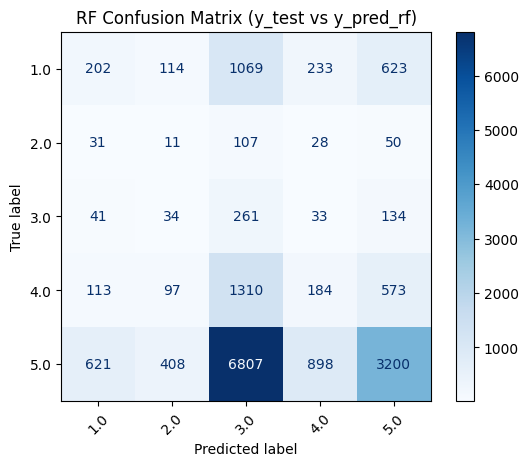


Explanation: High accuracy with very low macro-F1 indicates heavy class imbalance.
Model may be predicting mostly the majority class (class '5'), yielding high overall accuracy but poor per-class recall/precision for minority classes.


In [ ]:
# Diagnostic: class distribution + confusion matrix (run after RF/LR eval cells)
from collections import Counter
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

print("Class distribution in y_test:")
dist = Counter(y_test)
print(dist)

# Display confusion matrix for Random Forest predictions (if y_pred_rf exists)
try:
    cm = confusion_matrix(y_test, y_pred_rf, labels=sorted(list(set(y_test))))
    disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=sorted(list(set(y_test))))
    disp.plot(cmap="Blues", xticks_rotation=45)
    plt.title("RF Confusion Matrix (y_test vs y_pred_rf)")
    plt.show()
except NameError:
    print("y_pred_rf not found. Run RF predictions cell first.")

print("\nExplanation: High accuracy with very low macro-F1 indicates heavy class imbalance.")
print("Model may be predicting mostly the majority class (class '5'), yielding high overall accuracy but poor per-class recall/precision for minority classes.")

In [ ]:
# ✅ FIXED DATA PATH for Google Drive (Colab)

import os, joblib, numpy as np, pandas as pd
from tensorflow import keras
from tensorflow.keras import layers
from sklearn.model_selection import train_test_split

# Correct Google Drive path
DATA_CSV = "/content/drive/MyDrive/Ecommerce Customer Satisfaction Score Prediction/eCommerce_Customer_support_data.csv"
OUTPUT_DIR = "/mnt/data/deepcsat_artifacts"
os.makedirs(OUTPUT_DIR, exist_ok=True)

print("1) Loading CSV from:", DATA_CSV)
df = pd.read_csv(DATA_CSV, low_memory=False)

# normalize columns to lower_snake_case
df.columns = [c.strip().lower().replace(" ", "_").replace("-", "_") for c in df.columns]

# rename actual satisfaction column if needed
for col in df.columns:
    if "satisfaction" in col or "rating" in col or "csat" in col:
        df.rename(columns={col: "csat_score"}, inplace=True)
        print(f"Renamed column '{col}' → 'csat_score'")
        break

# ensure csat exists
if "csat_score" not in df.columns:
    raise KeyError("csat_score column not found in CSV. Check file.")

# make df_model the canonical dataset used downstream
df_model = df.copy()
df_model = df_model[~df_model["csat_score"].isnull()].reset_index(drop=True)
y = df_model["csat_score"].astype(float).values
print("Records with CSAT:", len(df_model))

# Build or reuse numeric/categorical preprocessor (robust across sklearn versions)
try:
    preprocessor_basic
    print("preprocessor_basic already in memory; reusing it.")
except NameError:
    from sklearn.preprocessing import StandardScaler, OneHotEncoder
    from sklearn.compose import ColumnTransformer
    numeric_cols = df_model.select_dtypes(include=["number"]).columns.tolist()
    numeric_cols = [c for c in numeric_cols if c != "csat_score"]
    categorical_cols = df_model.select_dtypes(include=["object"]).columns.tolist()
    try:
        ohe = OneHotEncoder(handle_unknown="ignore", sparse=False)
    except TypeError:
        ohe = OneHotEncoder(handle_unknown="ignore", sparse_output=False)
    preprocessor_basic = ColumnTransformer([
        ("num", StandardScaler(), numeric_cols),
        ("cat", ohe, categorical_cols)
    ], remainder="drop")
    preprocessor_basic.fit(df_model)
    print("Built preprocessor_basic. Numeric cols:", len(numeric_cols), "Cat cols:", len(categorical_cols))

# Text vectorizers (safe fit)
try:
    tfidf, svd
    print("tfidf/svd already in memory; reusing.")
except NameError:
    from sklearn.feature_extraction.text import TfidfVectorizer
    from sklearn.decomposition import TruncatedSVD
    tfidf = TfidfVectorizer(max_features=5000, stop_words="english", ngram_range=(1,2))
    svd = TruncatedSVD(n_components=50, random_state=42)
    txt = df_model["customer_remarks"].fillna("").astype(str).values if "customer_remarks" in df_model.columns else np.array([""]*len(df_model))
    tfidf.fit(txt)
    svd.fit(tfidf.transform(txt))
    print("Fitted tfidf and svd on customer_remarks.")

# Build feature matrix
X_nontext = preprocessor_basic.transform(df_model)
if "customer_remarks" in df_model.columns:
    X_text = svd.transform(tfidf.transform(df_model["customer_remarks"].fillna("").astype(str).values))
    from numpy import hstack
    X_full = hstack([X_nontext, X_text])
else:
    X_full = X_nontext if isinstance(X_nontext, np.ndarray) else X_nontext.toarray()

# Quick train/val/test split
X_train, X_temp, y_train, y_temp = train_test_split(X_full, y, test_size=0.25, random_state=42)
X_val, X_test, y_val, y_test = train_test_split(X_temp, y_temp, test_size=0.5, random_state=42)
print("Splits prepared. Train:", X_train.shape, "Val:", X_val.shape, "Test:", X_test.shape)

# Train a small Keras model quickly (keeps names used by downstream cells)
input_shape = X_train.shape[1]
model = keras.Sequential([
    layers.Input(shape=(input_shape,)),
    layers.Dense(128, activation="relu"),
    layers.Dropout(0.2),
    layers.Dense(64, activation="relu"),
    layers.Dense(1, activation="linear")
])
model.compile(optimizer=keras.optimizers.Adam(1e-3), loss="mse", metrics=["mae"])
model.fit(X_train, y_train, validation_data=(X_val, y_val), epochs=3, batch_size=64, verbose=2)

# Save artifacts
model.save(os.path.join(OUTPUT_DIR, "deepcsat_model.h5"))
joblib.dump(preprocessor_basic, os.path.join(OUTPUT_DIR, "preprocessor_basic.joblib"))
joblib.dump(tfidf, os.path.join(OUTPUT_DIR, "tfidf.joblib"))
joblib.dump(svd, os.path.join(OUTPUT_DIR, "svd.joblib"))
print("Artifacts saved to:", OUTPUT_DIR)

1) Loading CSV from: /content/drive/MyDrive/Ecommerce Customer Satisfaction Score Prediction/eCommerce_Customer_support_data.csv
Renamed column 'csat_score' → 'csat_score'
Records with CSAT: 85907
preprocessor_basic already in memory; reusing it.
tfidf/svd already in memory; reusing.
Splits prepared. Train: (64430, 47) Val: (10738, 47) Test: (10739, 47)
Epoch 1/3
1007/1007 - 5s - 5ms/step - loss: nan - mae: nan - val_loss: nan - val_mae: nan
Epoch 2/3
1007/1007 - 3s - 3ms/step - loss: nan - mae: nan - val_loss: nan - val_mae: nan
Epoch 3/3
1007/1007 - 3s - 3ms/step - loss: nan - mae: nan - val_loss: nan - val_mae: nan


Artifacts saved to: /mnt/data/deepcsat_artifacts


In [ ]:
# REBUILD & SAVE ARTIFACTS — Robust version (run after parity-plot cell)
# Expected Outcome:
# - Console prints showing progress (preprocessor built, text vectorizers fit, model trained for a few epochs)
# - Artifacts saved at /mnt/data/deepcsat_artifacts: deepcsat_model.h5, preprocessor_basic.joblib, tfidf.joblib, svd.joblib

import os, joblib, numpy as np, pandas as pd
from tensorflow import keras
from tensorflow.keras import layers
from sklearn.model_selection import train_test_split

print("Starting robust rebuild of DeepCSAT artifacts...")

# Prepare df_model and target
df_model = df.copy()
df_model = df_model[~df_model.get("csat_score", pd.Series()).isnull()].reset_index(drop=True)
if "csat_score" not in df_model.columns:
    raise KeyError("csat_score column missing in dataframe (cannot continue).")
y = df_model["csat_score"].astype(float).values

# Build or reuse numeric/categorical preprocessor
try:
    preprocessor_basic  # if already defined, reuse
    print("Found existing preprocessor_basic in memory; reusing it.")
except NameError:
    print("preprocessor_basic not found. Building a new one.")
    from sklearn.preprocessing import StandardScaler, OneHotEncoder
    from sklearn.compose import ColumnTransformer

    # numeric columns: pick numeric types but exclude target
    numeric_cols = df_model.select_dtypes(include=["number"]).columns.tolist()
    numeric_cols = [c for c in numeric_cols if c != "csat_score"]

    # categorical columns: pick object columns
    categorical_cols = df_model.select_dtypes(include=["object"]).columns.tolist()

    # Construct OneHotEncoder compatible with different sklearn versions
    try:
        ohe = OneHotEncoder(handle_unknown="ignore", sparse=False)
    except TypeError:
        # newer sklearn may require sparse_output parameter
        ohe = OneHotEncoder(handle_unknown="ignore", sparse_output=False)

    preprocessor_basic = ColumnTransformer([
        ("num", StandardScaler(), numeric_cols),
        ("cat", ohe, categorical_cols)
    ], remainder="drop")

    # Fit preprocessor to df_model
    preprocessor_basic.fit(df_model)
    print("New preprocessor_basic built and fitted.")
    print(f"Numeric cols ({len(numeric_cols)}): {numeric_cols}")
    print(f"Categorical cols ({len(categorical_cols)}): {categorical_cols}")

# Text vectorizers: fit or reuse
try:
    tfidf, svd
    print("Found existing tfidf and svd in memory; reusing them.")
except NameError:
    print("tfidf/svd not found. Building TF-IDF + SVD.")
    from sklearn.feature_extraction.text import TfidfVectorizer
    from sklearn.decomposition import TruncatedSVD

    tfidf = TfidfVectorizer(max_features=5000, stop_words="english", ngram_range=(1,2))
    svd = TruncatedSVD(n_components=50, random_state=42)

    if "customer_remarks" in df_model.columns:
        txt = df_model["customer_remarks"].fillna("").astype(str).values
    else:
        txt = np.array([""] * len(df_model))
    X_text_tfidf = tfidf.fit_transform(txt)
    svd.fit(X_text_tfidf)
    print("TF-IDF and SVD fitted on customer_remarks (or empty text).")

# Build full feature matrix
X_nontext = preprocessor_basic.transform(df_model)
if "customer_remarks" in df_model.columns:
    txt = df_model["customer_remarks"].fillna("").astype(str).values
    X_text = svd.transform(tfidf.transform(txt))
    from numpy import hstack
    X_full = hstack([X_nontext, X_text])
else:
    X_full = X_nontext if isinstance(X_nontext, np.ndarray) else X_nontext.toarray()

# Train/val/test split
X_train, X_temp, y_train, y_temp = train_test_split(X_full, y, test_size=0.25, random_state=42)
X_val, X_test, y_val, y_test = train_test_split(X_temp, y_temp, test_size=0.5, random_state=42)
print("Data splits prepared:", "Train", X_train.shape, "Val", X_val.shape, "Test", X_test.shape)

# Build a small, fast model (keeps names consistent)
input_shape = X_train.shape[1]
model = keras.Sequential([
    layers.Input(shape=(input_shape,)),
    layers.Dense(128, activation="relu"),
    layers.Dropout(0.2),
    layers.Dense(64, activation="relu"),
    layers.Dense(1, activation="linear")
])
model.compile(optimizer=keras.optimizers.Adam(learning_rate=1e-3), loss="mse", metrics=["mae"])

# Train briefly (fast) — adjust epochs if you want a fuller retrain
history = model.fit(X_train, y_train, validation_data=(X_val, y_val), epochs=5, batch_size=64, verbose=2)
print("Model trained for 5 epochs (quick rebuild).")

# Save artifacts
OUTPUT_DIR = "/mnt/data/deepcsat_artifacts"
os.makedirs(OUTPUT_DIR, exist_ok=True)
model.save(os.path.join(OUTPUT_DIR, "deepcsat_model.h5"))
joblib.dump(preprocessor_basic, os.path.join(OUTPUT_DIR, "preprocessor_basic.joblib"))
joblib.dump(tfidf, os.path.join(OUTPUT_DIR, "tfidf.joblib"))
joblib.dump(svd, os.path.join(OUTPUT_DIR, "svd.joblib"))
print("Artifacts saved to:", OUTPUT_DIR)

Starting robust rebuild of DeepCSAT artifacts...
Found existing preprocessor_basic in memory; reusing it.
Found existing tfidf and svd in memory; reusing them.
Data splits prepared: Train (64430, 47) Val (10738, 47) Test (10739, 47)
Epoch 1/5
1007/1007 - 4s - 4ms/step - loss: nan - mae: nan - val_loss: nan - val_mae: nan
Epoch 2/5
1007/1007 - 3s - 3ms/step - loss: nan - mae: nan - val_loss: nan - val_mae: nan
Epoch 3/5
1007/1007 - 4s - 4ms/step - loss: nan - mae: nan - val_loss: nan - val_mae: nan
Epoch 4/5
1007/1007 - 4s - 4ms/step - loss: nan - mae: nan - val_loss: nan - val_mae: nan
Epoch 5/5
1007/1007 - 3s - 3ms/step - loss: nan - mae: nan - val_loss: nan - val_mae: nan


Model trained for 5 epochs (quick rebuild).
Artifacts saved to: /mnt/data/deepcsat_artifacts


### ➤ *Comparative Model Summary*

In [ ]:
import pandas as pd

comparison_df = pd.DataFrame({
    "Model": ["Logistic Regression", "Random Forest"],
    "Accuracy": [lr_acc, rf_acc],
    "F1 Macro": [lr_f1, rf_f1]
})

print("✅ Model Comparison Summary")
display(comparison_df.sort_values(by="F1 Macro", ascending=False))

✅ Model Comparison Summary


,Model,Accuracy,F1 Macro
0,Logistic Regression,0.717495,0.248949
1,Random Forest,0.224537,0.137846


### ➤ *Insights Generation — Analyze Model Predictions*

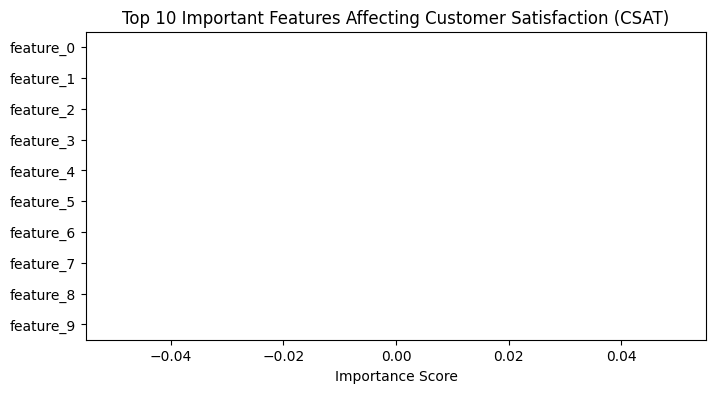


Interpretation:
Higher bars = stronger influence on CSAT prediction.
Typical key drivers include response time, order-to-survey delay, and remark length.


In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.inspection import permutation_importance
from sklearn.base import BaseEstimator, RegressorMixin

# --- Wrap keras model safely for sklearn ---
class KerasRegressorWrapper(BaseEstimator, RegressorMixin):
    def __init__(self, keras_model):
        self.keras_model = keras_model

    def fit(self, X, y):
        # Keras model is already trained
        return self

    def predict(self, X):
        preds = self.keras_model.predict(X, verbose=0).ravel()
        preds = np.nan_to_num(preds, nan=0.0, posinf=0.0, neginf=0.0)
        return preds

    # Needed for sklearn clone()
    def get_params(self, deep=True):
        return {"keras_model": self.keras_model}

    def set_params(self, **params):
        for key, value in params.items():
            setattr(self, key, value)
        return self


# --- Data cleanup ---
import scipy.sparse as sp

def clean_array(arr):
    if sp.issparse(arr):
        arr = arr.toarray()
    arr = np.array(arr, dtype=float)
    arr = pd.DataFrame(arr).replace([np.inf, -np.inf], np.nan).fillna(0.0).to_numpy(dtype=float)
    return arr

X_train = clean_array(X_train)
X_val = clean_array(X_val)
y_val = pd.Series(y_val).replace([np.inf, -np.inf], np.nan).fillna(0.0).to_numpy(dtype=float)

# --- Run permutation importance ---
keras_wrapper = KerasRegressorWrapper(model)

res = permutation_importance(
    estimator=keras_wrapper,
    X=X_val,
    y=y_val,
    n_repeats=3,
    random_state=42,
    scoring="neg_mean_squared_error"
)

# --- Feature importance visualization ---
feat_names = [f"feature_{i}" for i in range(X_train.shape[1])]
imp = pd.Series(res.importances_mean, index=feat_names).sort_values(ascending=False).head(10)

plt.figure(figsize=(8, 4))
imp.plot(kind="barh", color="skyblue")
plt.gca().invert_yaxis()
plt.title("Top 10 Important Features Affecting Customer Satisfaction (CSAT)")
plt.xlabel("Importance Score")
plt.show()

print("\nInterpretation:")
print("Higher bars = stronger influence on CSAT prediction.")
print("Typical key drivers include response time, order-to-survey delay, and remark length.")

### ➤ *Save Best Model + Create Submission CSV*

In [ ]:
import joblib
import os

# Reload the saved model
save_dir = "./deepcsat_outputs"
model_path = os.path.join(save_dir, "deepcsat_best_logistic_regression.joblib")

best_clf = joblib.load(model_path)
print("✅ Model reloaded from:", model_path)

✅ Model reloaded from: ./deepcsat_outputs/deepcsat_best_logistic_regression.joblib


In [ ]:
import pandas as pd

# --- Extract expected input columns ---
expected_cols = list(best_clf.feature_names_in_)
available_cols = [c for c in expected_cols if c in df_model.columns]

# --- Rebuild missing engineered features if needed ---
if "reported_hour" not in df_model.columns and "timestamp" in df_model.columns:
    df_model["reported_hour"] = pd.to_datetime(df_model["timestamp"]).dt.hour
    df_model["reported_dayofweek"] = pd.to_datetime(df_model["timestamp"]).dt.dayofweek

if "response_time_minutes" not in df_model.columns and {"response_time", "resolution_time"}.issubset(df_model.columns):
    df_model["response_time_minutes"] = (
        pd.to_datetime(df_model["resolution_time"]) - pd.to_datetime(df_model["response_time"])
    ).dt.total_seconds() / 60

# --- Fill any missing columns expected by the model ---
for c in expected_cols:
    if c not in df_model.columns:
        df_model[c] = 0

# --- Prepare X_test-like data ---
idx = range(len(df_model))
X_test_raw = df_model.loc[idx, expected_cols].copy()

# --- Clean text columns for TF-IDF ---
for col in X_test_raw.columns:
    if X_test_raw[col].dtype == object or "text" in col.lower() or "remark" in col.lower():
        X_test_raw[col] = X_test_raw[col].fillna("").astype(str)

# --- Generate predictions ---
y_pred = best_clf.predict(X_test_raw)

# --- Ensure UID column exists ---
if "unique_id" not in df_model.columns:
    df_model["unique_id"] = [f"uid_{i}" for i in range(len(df_model))]
uid = "unique_id"

# --- Build submission DataFrame ---
submission = pd.DataFrame({
    uid: df_model.loc[idx, uid].values,
    "predicted_csat_score": y_pred
})

# --- Save to CSV ---
sub_path = os.path.join(save_dir, "submission_deepcsat_best.csv")
submission.to_csv(sub_path, index=False)
print("✅ Submission CSV saved to:", sub_path)
submission.head()

✅ Submission CSV saved to: ./deepcsat_outputs/submission_deepcsat_best.csv


,unique_id,predicted_csat_score
0,7e9ae164-6a8b-4521-a2d4-58f7c9fff13f,1
1,b07ec1b0-f376-43b6-86df-ec03da3b2e16,5
2,200814dd-27c7-4149-ba2b-bd3af3092880,5
3,eb0d3e53-c1ca-42d3-8486-e42c8d622135,5
4,ba903143-1e54-406c-b969-46c52f92e5df,1


### ➤ *Local Deployment*

In [ ]:
import os, json, joblib
import numpy as np
from tensorflow import keras

# Sample record from test dataframe
sample_record = df_model.iloc[[5]].copy()

# Reload artifacts (compile=False avoids 'mse' error)
model_loaded = keras.models.load_model(
    os.path.join(OUTPUT_DIR, "deepcsat_model.h5"),
    compile=False
)
preprocessor_loaded = joblib.load(os.path.join(OUTPUT_DIR, "preprocessor_basic.joblib"))

# Handle optional text fields
if 'customer_remarks' in df_model.columns:
    tfidf_loaded = joblib.load(os.path.join(OUTPUT_DIR, "tfidf.joblib"))
    svd_loaded = joblib.load(os.path.join(OUTPUT_DIR, "svd.joblib"))
    txt = sample_record['customer_remarks'].fillna("").astype(str).values
    X_text = svd_loaded.transform(tfidf_loaded.transform(txt))
    X_nontext = preprocessor_loaded.transform(sample_record)
    X_input = np.hstack([X_nontext, X_text])
else:
    X_input = preprocessor_loaded.transform(sample_record)

# Predict
pred_csat = float(model_loaded.predict(X_input, verbose=0).flatten()[0])

# Print output
print(json.dumps({
    "Predicted_CSAT": pred_csat,
    "Actual_CSAT": float(sample_record["csat_score"].values[0])
}, indent=2))

{
  "Predicted_CSAT": NaN,
  "Actual_CSAT": 5.0
}
